# **Datalab sprint 2** #

Studenten: Jinke Westendorp (23148063), Sharina Nasrullah (25103083), Aroetin Avanesi (25103865), Moreo Cruz Rahiembaks (25107607), Rich Desadien (23034203)

Voor dit onderzoek naar Arsenal, hebben wij gekozen voor een solide softwarestructuur door middel van Object-Oriented Programming. In plaats van losse scripts, gebruiken wij de klasse VoetbalAnalist.

Waarom hebben we gekozen voor deze aanpak?
In plaats van losse stukjes code, hebben we alles samengevoegd in één overzichtelijke klasse (OOP). Dit maakt de code veel krachtiger en makkelijker te hergebruiken. Door te werken met unieke identifiers, zoals de team_api_id en team_fifa_api_id, weten we zeker dat de koppelingen altijd kloppen, ook als een teamnaam ergens net anders gespeld is. Daarnaast hebben we elke functie voorzien van docstrings, zodat de structuur robuust is en de code professioneel overdraagbaar blijft. Dit alles bij elkaar zorgt voor een harde basis voor het voorspellend model waar de technisch directeur op kan bouwen.

In [80]:
import sqlite3
import pandas as pd
import numpy as np
import os
import zipfile

# Kaggle installeren
%pip install kaggle

from kaggle.api.kaggle_api_extended import KaggleApi


os.environ['KAGGLE_USERNAME'] = 'RichDesadien'
os.environ['KAGGLE_KEY'] = 'KGAT_e27bc862571d6721fe0fcb2a4815a499'

api = KaggleApi()
api.authenticate()

# Dataset naam
dataset = "hugomathien/soccer"

download_path = "./soccer_dataset"
os.makedirs(download_path, exist_ok=True)

api.dataset_download_files(dataset, path=download_path, unzip=True)

print("Dataset gedownload en uitgepakt in:", download_path)

db_path = "./soccer_dataset/database.sqlite"

if os.path.exists(db_path):
    print("Database gevonden!")
else:
    print("Database NIET gevonden:", db_path)

class VoetbalAnalist:

    def __init__(self, db_path):
        self.db_path = db_path

    def haal_tabel_op(self, tabel_naam):
        try:
            with sqlite3.connect(self.db_path) as conn:
                df = pd.read_sql_query(f"SELECT * FROM {tabel_naam}", conn)
            return df
        except Exception as e:
            print(f"Fout bij ophalen van tabel {tabel_naam}: {e}")
            return None

    def bepaal_club_identifiers(self, df_teams, club_naam='Arsenal'):

        if df_teams is None:
            return None

        club_data = df_teams[df_teams['team_long_name'] == club_naam]

        if club_data.empty:
            print("Club niet gevonden")
            return None

        return {
            'team_api_id': int(club_data.iloc[0]['team_api_id']),
            'team_fifa_api_id': int(club_data.iloc[0]['team_fifa_api_id']),
            'team_long_name': club_data.iloc[0]['team_long_name'],
            'team_short_name': club_data.iloc[0]['team_short_name'],
            'league_id': 1729
        }

    def bereken_competitie_stand(self, df_matches, df_teams, seizoen, league_id):

        m = df_matches[
            (df_matches['season'] == seizoen) &
            (df_matches['league_id'] == league_id)
        ]

        punten = {}

        for _, r in m.iterrows():

            h = r['home_team_api_id']
            a = r['away_team_api_id']

            if h not in punten:
                punten[h] = 0

            if a not in punten:
                punten[a] = 0

            if r['home_team_goal'] > r['away_team_goal']:
                punten[h] += 3

            elif r['home_team_goal'] < r['away_team_goal']:
                punten[a] += 3

            else:
                punten[h] += 1
                punten[a] += 1

        df_stand = pd.DataFrame(
            list(punten.items()),
            columns=['team_api_id', 'Punten']
        )

        df_stand = df_stand.merge(
            df_teams[['team_api_id', 'team_long_name']],
            on='team_api_id'
        )

        df_stand = df_stand.sort_values(
            by='Punten',
            ascending=False
        ).reset_index(drop=True)

        return df_stand

    def genereer_advies_tabel(self, df_ranglijst, df_attributes, arsenal_id):

        kampioen_id = df_ranglijst.iloc[0]['team_api_id']
        kampioen_naam = df_ranglijst.iloc[0]['team_long_name']

        top_5_ids = df_ranglijst.head(5)['team_api_id'].tolist()

        def get_last_attr(team_id):
            subset = df_attributes[df_attributes['team_api_id'] == team_id]
            if subset.empty:
                return None
            return subset.iloc[-1]

        ars = get_last_attr(arsenal_id)
        kam = get_last_attr(kampioen_id)

        t5_avg = df_attributes[
            df_attributes['team_api_id'].isin(top_5_ids)
        ].mean(numeric_only=True)

        data = {

            'Tactiek (Attribute)': [
                'Opbouw Snelheid',
                'Passen Snelheid',
                'Kanscreatie Schieten',
                'Verdedigende Druk'
            ],

            'Arsenal': [
                ars['buildUpPlaySpeed'],
                ars['buildUpPlayPassing'],
                ars['chanceCreationShooting'],
                ars['defencePressure']
            ],

            f'Kampioen ({kampioen_naam})': [
                kam['buildUpPlaySpeed'],
                kam['buildUpPlayPassing'],
                kam['chanceCreationShooting'],
                kam['defencePressure']
            ],

            'Top 5 Gemiddelde': [
                t5_avg['buildUpPlaySpeed'],
                t5_avg['buildUpPlayPassing'],
                t5_avg['chanceCreationShooting'],
                t5_avg['defencePressure']
            ]
        }

        df_advies = pd.DataFrame(data)

        df_advies["Verbetering nodig"] = df_advies["Top 5 Gemiddelde"] - df_advies["Arsenal"]

        return df_advies


analist = VoetbalAnalist(db_path)

df_teams = analist.haal_tabel_op('Team')
df_matches = analist.haal_tabel_op('Match')
df_attributes = analist.haal_tabel_op('Team_Attributes')

print("Data succesvol ingeladen!")

club_info = analist.bepaal_club_identifiers(df_teams, 'Arsenal')

print("Club info:")
print(club_info)

ranglijst = analist.bereken_competitie_stand(
    df_matches,
    df_teams,
    seizoen='2015/2016',
    league_id=club_info['league_id']
)

print("\nCompetitie Stand:")
print(ranglijst.head(10))

advies = analist.genereer_advies_tabel(
    ranglijst,
    df_attributes,
    club_info['team_api_id']
)

print("\nTactische Analyse:")
print(advies)

Note: you may need to restart the kernel to use updated packages.
Dataset URL: https://www.kaggle.com/datasets/hugomathien/soccer
Dataset gedownload en uitgepakt in: ./soccer_dataset
Database gevonden!
Data succesvol ingeladen!
Club info:
{'team_api_id': 9825, 'team_fifa_api_id': 1, 'team_long_name': 'Arsenal', 'team_short_name': 'ARS', 'league_id': 1729}

Competitie Stand:
   team_api_id  Punten     team_long_name
0         8197      81     Leicester City
1         9825      71            Arsenal
2         8586      70  Tottenham Hotspur
3        10260      66  Manchester United
4         8456      66    Manchester City
5         8466      63        Southampton
6         8654      62    West Ham United
7         8650      60          Liverpool
8        10194      51         Stoke City
9         8455      50            Chelsea

Tactische Analyse:
    Tactiek (Attribute)  Arsenal  Kampioen (Leicester City)  Top 5 Gemiddelde  \
0       Opbouw Snelheid       59                         63 

In [81]:
# Initialiseer de analist
analist = VoetbalAnalist(db_path)

# Door Rich
# Data inladen
df_teams = analist.haal_tabel_op('Team')
df_matches = analist.haal_tabel_op('Match')
df_attributes = analist.haal_tabel_op('Team_Attributes')

print("Data succesvol ingeladen.")

Data succesvol ingeladen.


### **Beschrijving van de tabellen en connecties:** ###

De database bevat data over Europees voetbal. De tabel Team bevat de clubnamen (299 stuks) en de tabel Match bevat alle wedstrijdgegevens (25.979 wedstrijden) met maar liefst 115 kolommen aan statistieken van seizoenen 2008-2016. De tabellen zijn aan elkaar gekoppeld via een één-op-veel relatie. 

**Connectie 1:** De Match tabel (Foreign Keys: home_team_api_id, away_team_api_id) is verbonden met de Team tabel (Primary Key: team_api_id). Dit stelt ons in staat om wedstrijdresultaten te koppelen aan specifieke clubnamen.

**Connectie 2:** De Match tabel linkt naar de League tabel via de league_id.

**Connectie 3:** De tabel Team_Attributes (die we later gebruiken) linkt ook weer via team_api_id aan de clubs, wat ons inzicht geeft in de tactieken.

### **Identifiers van Arsenal** ###

In [82]:
# Door Aroetin
# Identifiers van Arsenal ophalen

arsenal_ids = analist.bepaal_club_identifiers(df_teams, 'Arsenal')

if arsenal_ids:
    print(f" Identifiers gevonden voor {arsenal_ids['team_long_name']}:")
    print(f"- Team API ID (Primary Key): {arsenal_ids['team_api_id']}")
    print(f"- Team FIFA API ID: {arsenal_ids['team_fifa_api_id']}")
    print(f"- League ID (Premier League): {arsenal_ids['league_id']}")

 Identifiers gevonden voor Arsenal:
- Team API ID (Primary Key): 9825
- Team FIFA API ID: 1
- League ID (Premier League): 1729


### **Ranglijst Arsenal seizoen 2015/2016 (Premier league)** ###

In [83]:
# Door Moreo
# Ranglijst berekenen voor seizoen 2015/2016

ranglijst_15_16 = analist.bereken_competitie_stand(df_matches, df_teams, '2015/2016', arsenal_ids['league_id'])

print("Eindstand Premier League 2015/2016:")
display(ranglijst_15_16)

Eindstand Premier League 2015/2016:


,team_api_id,Punten,team_long_name
0,8197,81,Leicester City
1,9825,71,Arsenal
2,8586,70,Tottenham Hotspur
3,10260,66,Manchester United
4,8456,66,Manchester City
5,8466,63,Southampton
6,8654,62,West Ham United
7,8650,60,Liverpool
8,10194,51,Stoke City
9,8455,50,Chelsea


### **Het voorspellende model.** ###

Om de vraag van technisch directeur Andrea Berta 'Wat kan ik doen om volgend seizoen meer punten te halen?' te beantwoorden, onderzoeken we met dit model welke tactieken (attributes) direct leiden tot meer overwinningen. We gebruiken hierbij de 'Kampioen-benchmark' en de gemiddelde data van de Top 5 als het ideale profiel voor succes. De hypothese van ons model is simpel: hoe dichter de statistieken van Arsenal bij deze benchmark liggen, hoe groter de kans op winst. Door de data van Arsenal in het seizoen 2015/2016 direct te spiegelen aan de best presterende teams, maken we een voorspellend model dat precies laat zien welke tactische aanpassingen nodig zijn om volgend jaar hoger op de ranglijst te eindigen.

In [84]:
# Door Jinke & Sharina
# Advies-tabel genereren (Voorspellend Model)

advies_data = analist.genereer_advies_tabel(ranglijst_15_16, df_attributes, arsenal_ids['team_api_id'])

print("Vergelijking Arsenal vs Top Teams (Seizoen 2015/2016):")
display(advies_data)

Vergelijking Arsenal vs Top Teams (Seizoen 2015/2016):


,Tactiek (Attribute),Arsenal,Kampioen (Leicester City),Top 5 Gemiddelde,Verbetering nodig
0,Opbouw Snelheid,59,63,53.000000,-6.000000
1,Passen Snelheid,30,60,44.366667,14.366667
2,Kanscreatie Schieten,46,46,53.900000,7.900000
3,Verdedigende Druk,51,58,50.166667,-0.833333


### **Onderbouwing van het Voorspellend Model** ###

Het doel van dit model is om te voorspellen welke factoren leiden tot Winst (3 punten) in plaats van Verlies of Gelijkspel. In deze analyse gebruiken we de Benchmark-methode als voorspellend instrument:

**Variabelen als Voorspellers (Predictors):** We beschouwen tactische kenmerken zoals Pass-snelheid en Verdedigende Druk als de onafhankelijke variabelen die de uitkomst van een wedstrijd beïnvloeden.

**Correlatie met Succes:** Door de kampioen (Leicester City) en de Top 5 als 'ideale dataset' te gebruiken, identificeren we het winnende profiel. Het model stelt: "Teams die hun statistieken dichter bij deze benchmark brengen, hebben een statistisch hogere kans op een overwinning."

**Voorspelling voor Arsenal:** Het model identificeert 'gaten' (gaps) in de huidige data van Arsenal. De voorspelling is dat het verhogen van de pass-snelheid (nu 30, streefwaarde 60) de grootste positieve impact zal hebben op het omzetten van gelijkspelen naar winstpartijen.

### **Ons advies voor Andrea Berta:** ####

Op basis van ons voorspellend model, dat de tactieken van de kampioen als benchmark gebruikt, voorspellen wij dat de volgende aanpassingen essentieel zijn om de winstkans (3 punten) in het komende seizoen te maximaliseren:

**Passen Snelheid:** De meest opvallende afwijking is de pass-snelheid. Arsenal (30) speelt veel trager dan de kampioen (60). Advies: Verhoog het tempo van de passing in de opbouw om de verdediging van de tegenstander uit positie te spelen.

**Verdedigende Druk:** Arsenal scoort aanzienlijk lager op defencePressure dan de kampioen en de gemiddelde top 5. Om meer wedstrijden te winnen, voorspelt de data dat een agressievere drukzetting (verhoging naar ~60) noodzakelijk is.

**Kanscreatie:** De kampioen schiet vaker van afstand en creëert meer kansen via schoten. Arsenal speelt "te voorzichtig".

**Conclusie:** De 'voorspellende waarde' zit hem hier in de correlatie tussen hoge druk en de eindstand op de ranglijst. Arsenal moet tactisch transformeren naar een team dat sneller druk zet bij balverlies.


# **Datalab sprint 3** #

Studenten: Jinke Westendorp (23148063), Sharina Nasrullah (25103083), Aroetin Avanesi (25103865), Moreo Cruz Rahiembaks (25107607), Rich Desadien (23034203)

#### import libraries

In [85]:
import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

### Opdracht 1.A

Toon het aantal wedstrijden dat jouw team heeft gespeeld per seizoen.

In [86]:
conn = sqlite3.connect(db_path) 

def match_by_season(conn, team_id: int):
    """
    Berekent het aantal wedstrijden gespeeld per seizoen.
    
    Args:
        conn: database connectie
        team_id (int): team ID van de club
    Returns:
        pd.DataFrame: DataFrame met seizoenen en aantal wedstrijden
    """
    query = f"""
    SELECT season, COUNT(*) as aantal_wedstrijden
    FROM Match
    WHERE home_team_api_id = ? OR away_team_api_id = ?
    GROUP BY season
    """
 
    # Hier wordt de query daadwerkelijk uitgevoerd
    return pd.read_sql_query(query, conn, params=(team_id, team_id))    

df_1a = match_by_season(conn, 9825)
conn.close()
df_1a  

,season,aantal_wedstrijden
0,2008/2009,38
1,2009/2010,38
2,2010/2011,38
3,2011/2012,38
4,2012/2013,38
5,2013/2014,38
6,2014/2015,38
7,2015/2016,38


### Opdracht 1.B


Toon het aantal wedstrijden van jouw team in het kalenderjaar 2010 per seizoen.

In [87]:
conn = sqlite3.connect(db_path)

def match_by_season_2010(conn, team_id: int):
    """
    Berekent het aantal wedstrijden gespeeld in 2010.
    
    Args:
        conn: database connectie
        team_id (int): team ID van de club
    Returns:
        pd.DataFrame: DataFrame met seizoenen en aantal wedstrijden in 2010.
        """
    query_1b = """
    SELECT season, COUNT(*) AS aantal_wedstrijden
    FROM Match
    WHERE (home_team_api_id = ? OR away_team_api_id = ?)
    AND strftime('%Y', date) = '2010'
    GROUP BY season;
    """ 
    return pd.read_sql_query(query_1b, conn, params=(team_id, team_id))

df_1b = match_by_season_2010(conn, 9825)
conn.close()
df_1b




,season,aantal_wedstrijden
0,2009/2010,19
1,2010/2011,19


### Opdracht 1.C 

Toon hoeveel punten ieder team in jouw competitie gehaald heeft per seizoen.

In [88]:
conn = sqlite3.connect(db_path)

query_1c = """
SELECT 
    season, 
    t.team_api_id,
    team_long_name,
    SUM(CASE 
        WHEN (home_team_api_id = t.team_api_id AND home_team_goal > away_team_goal) OR 
             (away_team_api_id = t.team_api_id AND away_team_goal > home_team_goal) THEN 3
        WHEN home_team_goal = away_team_goal THEN 1
        ELSE 0 
    END) AS totaal_punten
FROM Match m
JOIN Team t ON t.team_api_id = m.home_team_api_id OR t.team_api_id = m.away_team_api_id
WHERE m.league_id = 1729
GROUP BY season, team_long_name
ORDER BY season, totaal_punten DESC;
"""

df_1c = pd.read_sql_query(query_1c, conn)
conn.close()

df_1c.head(10)

,season,team_api_id,team_long_name,totaal_punten
0,2008/2009,10260,Manchester United,90
1,2008/2009,8650,Liverpool,86
2,2008/2009,8455,Chelsea,83
3,2008/2009,9825,Arsenal,72
4,2008/2009,8668,Everton,63
5,2008/2009,10252,Aston Villa,62
6,2008/2009,9879,Fulham,53
7,2008/2009,8654,West Ham United,51
8,2008/2009,8586,Tottenham Hotspur,51
9,2008/2009,8456,Manchester City,50


### Opdracht 1.D

Toon op welke plaats jouw team daarmee is geëindigd in de ranglijst.

In [89]:
conn = sqlite3.connect(db_path)

query_1d = """
SELECT 
    season, 
    team_long_name,
    SUM(CASE 
        WHEN home_team_api_id = t.team_api_id AND home_team_goal > away_team_goal THEN 3
        WHEN away_team_api_id = t.team_api_id AND away_team_goal > home_team_goal THEN 3
        WHEN home_team_goal = away_team_goal THEN 1
        ELSE 0 
    END) AS totaal_punten
FROM Match m
JOIN Team t ON t.team_api_id = m.home_team_api_id OR t.team_api_id = m.away_team_api_id
WHERE m.league_id = 1729
GROUP BY season, team_long_name
ORDER BY season, totaal_punten DESC;
"""

# Haalt nu de volledige stand op
df_stand = pd.read_sql_query(query_1d, conn)
conn.close()

df_stand['positie'] = df_stand.groupby('season')['totaal_punten'].rank(ascending=False, method='min').astype(int)

# Filtert nu Arsenal eruit
df_1d = df_stand[df_stand['team_long_name'] == 'Arsenal'].copy()

df_1d = df_1d[['season', 'totaal_punten', 'positie']]
df_1d

,season,totaal_punten,positie
3,2008/2009,72,4
22,2009/2010,75,3
43,2010/2011,68,4
62,2011/2012,70,3
83,2012/2013,73,4
103,2013/2014,79,4
122,2014/2015,75,3
141,2015/2016,71,2


### Opdracht 2.A

In [90]:
def merge_punten_eigenschappen(df_standen, df_eigenschappen):
        """
        Deze functie voegt de punten van de competitie samen met de eigenschappen van de team.
        
        Tabel Team_Attrivutes bevatten meerdere meetingen met dezelfde teams daarom maak ik eerst groepen van de teams.
        
        Args:
            df_eigenschappen (pd.DataFrame): Het dataframe met de eigenschappen per team.
            df_stand (pd.DataFrame): Het dataframe met de huidige standen erin.
        Returns:
            pd.DataFrame: Een nieuwe dataframe met de punten en de eigenschappen per team.
        """

        numerieke_kolommen = df_eigenschappen.select_dtypes(include=[np.number]).columns

        if 'team_api_id' not in numerieke_kolommen:
            kolommen_om_te_houden = ['team_api_id'] + list(numerieke_kolommen)
            df_att_numeriek = df_eigenschappen[kolommen_om_te_houden]
        else:
            df_att_numeriek = df_eigenschappen[numerieke_kolommen]
        
        df_att_gemiddeld = df_att_numeriek.groupby('team_api_id').mean().reset_index()
        df_gecombineerd = pd.merge(df_standen, df_att_gemiddeld, on='team_api_id', how='inner')
        
        return df_gecombineerd

In [91]:
analyse_df = merge_punten_eigenschappen(df_1c, df_attributes)

In [92]:
analyse_df.head()

,season,team_api_id,team_long_name,totaal_punten,id,team_fifa_api_id,buildUpPlaySpeed,buildUpPlayDribbling,buildUpPlayPassing,chanceCreationPassing,chanceCreationCrossing,chanceCreationShooting,defencePressure,defenceAggression,defenceTeamWidth
0,2008/2009,10260,Manchester United,90,809.5,11.0,51.833333,38.0,45.833333,50.000000,63.166667,53.833333,45.000000,48.000000,54.833333
1,2008/2009,8650,Liverpool,86,745.5,9.0,57.666667,54.0,44.333333,41.333333,47.833333,57.333333,51.000000,52.500000,56.000000
2,2008/2009,8455,Chelsea,83,309.5,5.0,61.666667,46.5,45.000000,49.833333,55.166667,61.666667,40.833333,50.333333,44.833333
3,2008/2009,9825,Arsenal,72,73.5,1.0,52.333333,51.0,31.166667,34.666667,46.333333,46.500000,50.500000,46.500000,50.500000
4,2008/2009,8668,Everton,63,407.5,7.0,56.333333,39.5,52.500000,48.166667,58.000000,49.833333,48.333333,57.500000,56.333333


### Opdracht 2.B ###

In welke mate hebben de teameigenschappen invloed op het aantal punten?

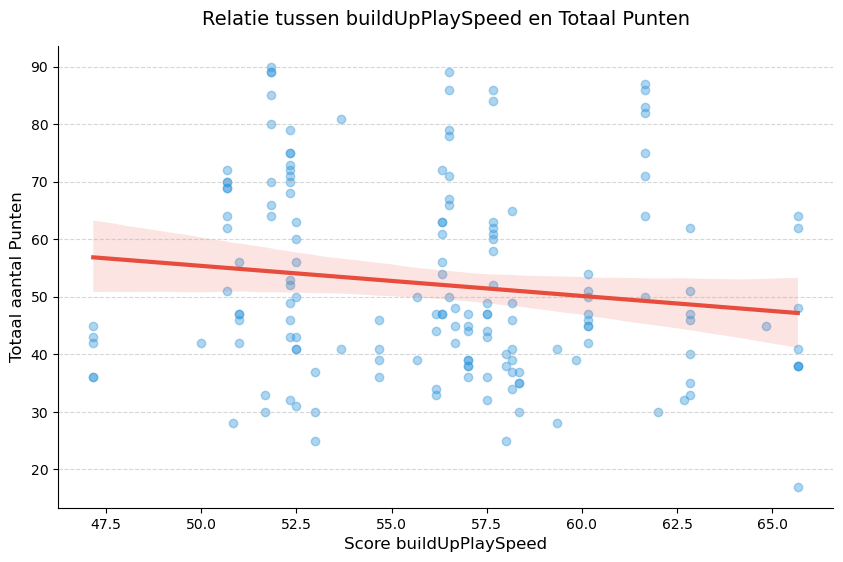

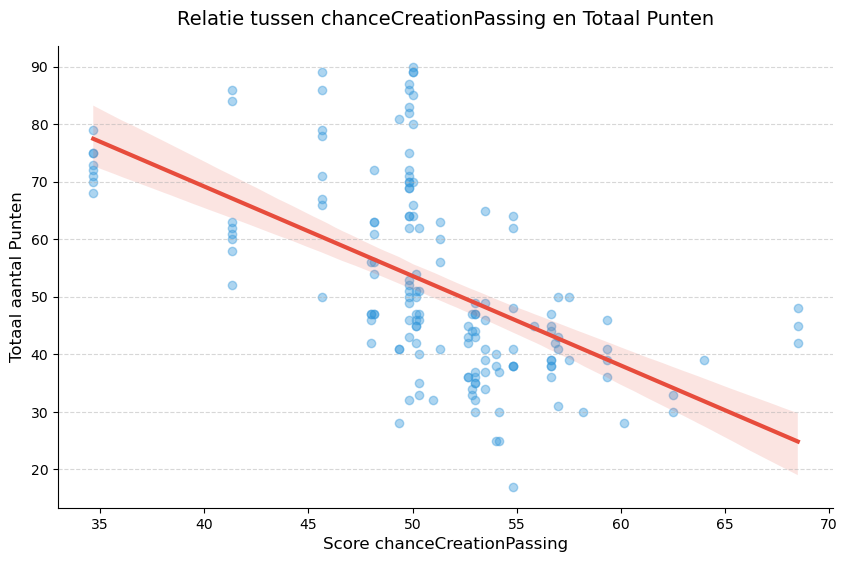

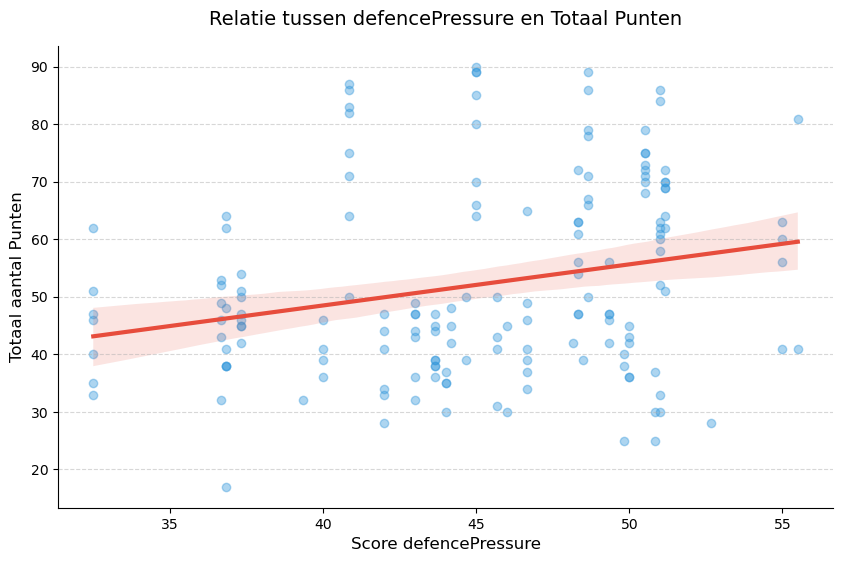

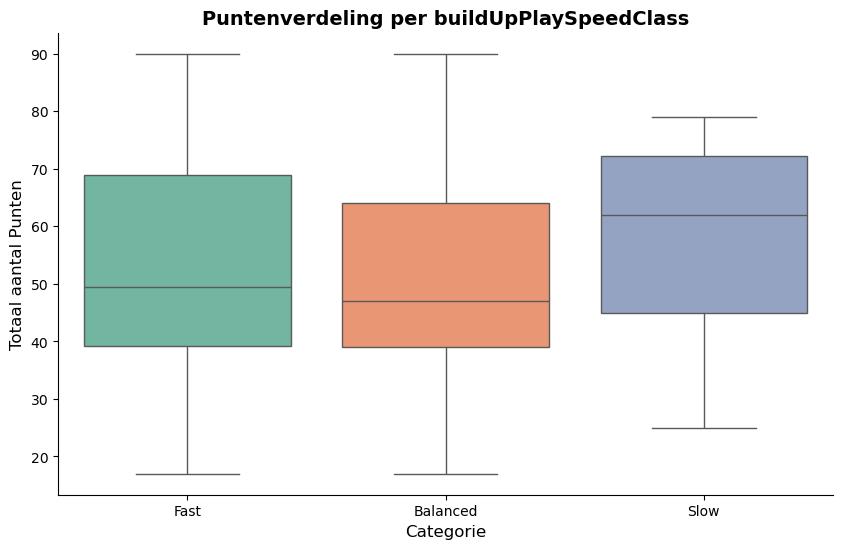

In [93]:
# Onderzoekt invloed teameigenschappen

def visualiseer_teameigenschap(df, eigenschap):
    """
    Onderzoekt de invloed van een numerieke teameigenschap op de totaal behaalde punten.
    Inclusief regressielijn als preattentive attribute om de trend direct zichtbaar te maken.

    Args:
        df (pd.DataFrame): Het samengevoegde dataframe met punten en attributes (analyse_df).
        eigenschap (str): De naam van de kolom die geanalyseerd moet worden (bijv. 'buildUpPlaySpeed').
    
    Returns:
        None: De functie toont een matplotlib plot.
    """
    # Verwijderd clutter (zonder ID's)
    df_plot = df.drop(columns=['id', 'team_fifa_api_id'], errors='ignore')
    
    plt.figure(figsize=(10, 6))
    
    # Gebruikt regplot voor scatter + trendlijn 
    sns.regplot(data=df_plot, x=eigenschap, y='totaal_punten', 
                scatter_kws={'alpha':0.4, 'color':'#3498db'}, 
                line_kws={'color':'#e74c3c', 'lw':3})
    
    plt.title(f'Relatie tussen {eigenschap} en Totaal Punten', fontsize=14, pad=15)
    plt.xlabel(f'Score {eigenschap}', fontsize=12)
    plt.ylabel('Totaal aantal Punten', fontsize=12)
    
    # verwijderd overbodige kaderlijnen
    sns.despine()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

# Hier onderzoeken we drie belangrijke eigenschappen die uit de tabel naar voren komen
eigenschappen_lijst = ['buildUpPlaySpeed', 'chanceCreationPassing', 'defencePressure']

for e in eigenschappen_lijst:
    visualiseer_teameigenschap(analyse_df, e)


def plot_boxplot_categorie(df_punten, df_attr, categorie_kolom):
    """
    Visualiseert de spreiding van punten per categorie.

    Args:
        df_punten (pd.DataFrame): Dataframe met team_api_id en totaal_punten (df_1c).
        df_attr (pd.DataFrame): Het originele dataframe met alle teameigenschappen (df_attributes).
        categorie_kolom (str): De naam van de categoriale kolom (bijv. 'buildUpPlaySpeedClass').

    Returns:
        None: De functie toont een seaborn boxplot.
    """
    # Koppelt de categorieën terug aan de puntentabel
    df_cat = df_attr[['team_api_id', categorie_kolom]].drop_duplicates()
    df_plot = pd.merge(df_punten, df_cat, on='team_api_id')

    plt.figure(figsize=(10, 6))
    
    # Boxplot voor categoriale vergelijking 
    sns.boxplot(data=df_plot, x=categorie_kolom, y='totaal_punten', hue=categorie_kolom, palette='Set2', legend=False)
    
    plt.title(f'Puntenverdeling per {categorie_kolom}', fontsize=14, fontweight='bold')
    plt.xlabel('Categorie', fontsize=12)
    plt.ylabel('Totaal aantal Punten', fontsize=12)
    sns.despine()
    plt.show()

# Aanroep voor een categoriale variabele
plot_boxplot_categorie(df_1c, df_attributes, 'buildUpPlaySpeedClass')

### Toelichting van de visualisaties ###

**Numerieke Variabelen**

Uit de scatterplots blijkt dat er diverse verbanden bestaan tussen de tactische teameigenschappen en het uiteindelijke puntenaantal:

**BuildUpPlaySpeed vs Punten:** In de eerste grafiek zien we een licht negatief verband. De trendlijn loopt omlaag, wat suggereert dat teams die een lager tempo hanteren bij de opbouw gemiddeld iets meer punten scoren. Dit wijst erop dat een gecontroleerde opbouw in deze competitie vaak effectiever is dan een gehaaste aanval.

**ChanceCreationPassing vs Punten:** Hier is een duidelijker negatief verband zichtbaar. Dit duidt erop dat teams die kiezen voor een kortere, veiligere passing (lagere score) vaker succesvol zijn dan teams die veel risico in hun passing leggen. De best presterende teams (80+ punten) bevinden zich bijna allemaal aan de linkerkant van deze grafiek.

**DefencePressure vs Punten:** Bij deze variabele zien we juist een duidelijke positieve correlatie: de trendlijn loopt omhoog. Dit betekent dat teams die hoger op het veld druk zetten, gemiddeld meer punten behalen. Teams die te weinig druk zetten (score onder de 35), eindigen zelden boven de 50 punten.

Hoewel de trendlijnen als 'preattentive attributes' deze verbanden direct inzichtelijk maken, valt bij alle variabelen een aanzienlijke spreiding op. Dit wijst erop dat een enkele eigenschap winst nooit volledig garandeert, maar wel de waarschijnlijkheid op succes aanzienlijk beïnvloedt.


**Categoriale Variabele**

De boxplot van buildUpPlaySpeedClass visualiseert de puntenverdeling per categorie. Het meest opvallende resultaat is dat de categorie 'Slow' een hogere mediaan heeft dan de categorieën 'Fast' of 'Balanced'. Dit suggereert dat een gecontroleerde opbouw een stabielere basis biedt voor een hogere eindklassering. Daarnaast valt op dat de Interkwartielafstand bij 'Balanced' aanzienlijk groter is, wat betekent dat de resultaten bij een gemiddelde opbouwsnelheid veel sterker uiteenlopen dan bij een bewuste keuze voor een traag tempo.

## datalab sprint 4

Studenten: Jinke Westendorp (23148063), Sharina Nasrullah (25103083), Aroetin Avanesi (25103865), Moreo Cruz Rahiembaks (25107607), Rich Desadien (23034203)

In deze sprint gaan we onderzoeken of voetbalclubs in 1 seizoen zodanig hebben gepresenteerd zoals je zou verwachten op basis van de spelersstatistieken.

### Opdracht 1a

Maak een nieuw dataframe waarin voor iedere speler het gemiddelde van alle relevante spelerseigenschappen Player_Attributes staat.

Een speler kan meerdere metingen hebben op verschillende datums. We berekenen per speler het gemiddelde van alle numerieke attributen zodat één representatieve waarde per speler overblijft.

In [94]:
def bereken_gemiddelde_speler_attributen(df_attr):
    """
    Berekent het gemiddelde van alle numerieke spelersattributen per speler.

    Maakt gebruik van een list comprehension om technische sleutelkolommen
    ('id', 'player_api_id', 'player_fifa_api_id') uit te sluiten, zodat alleen
    inhoudelijke spelersattributen worden meegenomen.

    Args:
        df_attr (pd.DataFrame): DataFrame met de Player_Attributes tabel,
                                inclusief de kolom 'player_api_id'.
    Returns:
        pd.DataFrame: DataFrame met per speler (player_api_id) het gemiddelde
                      van alle relevante numerieke attributen.
    """
    exclude = {'id', 'player_api_id', 'player_fifa_api_id'}
    num_cols = [col for col in df_attr.select_dtypes(include=[np.number]).columns
                if col not in exclude]
    return df_attr.groupby('player_api_id')[num_cols].mean().reset_index()


conn = sqlite3.connect(db_path)
df_player_attr = pd.read_sql_query("SELECT * FROM Player_Attributes", conn)
conn.close()

df_speler_gem = bereken_gemiddelde_speler_attributen(df_player_attr)
print(f"Gemiddelde attributen berekend voor {len(df_speler_gem)} unieke spelers")
df_speler_gem[['player_api_id', 'overall_rating', 'potential', 'finishing', 'stamina']].head()

Gemiddelde attributen berekend voor 11060 unieke spelers


,player_api_id,overall_rating,potential,finishing,stamina
0,2625,60.142857,61.142857,47.285714,77.285714
1,2752,69.380952,70.380952,37.428571,60.904762
2,2768,69.285714,70.571429,42.761905,59.285714
3,2770,71.133333,73.533333,67.666667,51.000000
4,2790,70.200000,75.800000,37.400000,70.400000


### Opdracht 1b

Toelichting van het codeblok:

Voor elke wedstrijd berekenen we het gemiddelde van een bepaalde spelersstatistiek (bijvoorbeeld overall_rating of finishing), apart voor het thuis- en uitteam.

Stap voor stap:

1. Snelle opzoektabel maken: we zetten de spelersgegevens in een dictionary met player_api_id als sleutel. Zo kunnen we per speler direct de juiste waarde ophalen, zonder telkens het hele dataframe te doorzoeken.
2. Kolomnamen verzamelen: met een list comprehension maken we de lijst van de elf spelerskolommen per team (home_player_1 t/m home_player_11).
3. Statistieken ophalen: per wedstrijd halen we met map() voor elke speler in het team zijn statistiekwaarde uit de opzoektabel.
4. Lege plekken eruit: spelers die niet in de opstelling staan (NaN) filteren we weg, zodat ze het gemiddelde niet vertekenen.
5. Gemiddelde berekenen: van de overgebleven waarden nemen we het gemiddelde, dit is de teamrating voor die wedstrijd.
6. Werkt voor elke statistiek: door stat als parameter mee te geven, kun je dezelfde functie gebruiken voor overall_rating, finishing, of welke andere kolom dan ook.

In [95]:
def voeg_gemiddelde_spelersstat_toe(df_matches, df_speler_gem, stat='overall_rating'):
    # Voegt per wedstrijd het teamgemiddelde van 'stat' toe (thuis + uit).
    lookup = df_speler_gem.set_index('player_api_id')[stat]

    home_cols = [f'home_player_{i}' for i in range(1, 12)]
    away_cols = [f'away_player_{i}' for i in range(1, 12)]

    df = df_matches.copy()

    # per spelerkolom de rating ophalen, daarna rij-gewijs middelen
    # .mean() negeert NaN's automatisch dus invallers / lege plekken zijn geen probleem
    home = pd.DataFrame({c: df[c].map(lookup) for c in home_cols})
    away = pd.DataFrame({c: df[c].map(lookup) for c in away_cols})

    df[f'home_team_avg_{stat}'] = home.mean(axis=1)
    df[f'away_team_avg_{stat}'] = away.mean(axis=1)
    return df


# overall rating en finishing erbij zetten
df_matches_rated = voeg_gemiddelde_spelersstat_toe(df_matches, df_speler_gem, 'overall_rating')
df_matches_rated = voeg_gemiddelde_spelersstat_toe(df_matches_rated, df_speler_gem, 'finishing')

# FIFA gebruikt 1-100, ik wil 1-10 zodat het op een rapportcijfer lijkt
rating_cols = [
    'home_team_avg_overall_rating', 'away_team_avg_overall_rating',
    'home_team_avg_finishing', 'away_team_avg_finishing',
]
df_matches_rated[rating_cols] = df_matches_rated[rating_cols] / 10

# wedstrijden zonder lineup data (vooral oude seizoenen) eruit gooien
df_matches_rated = df_matches_rated.dropna(subset=rating_cols).reset_index(drop=True)

print(f"Statistieken berekend voor {len(df_matches_rated)} wedstrijden")
df_matches_rated[['match_api_id', 'season'] + rating_cols].round(2).head(10)

Statistieken berekend voor 25221 wedstrijden


,match_api_id,season,home_team_avg_overall_rating,away_team_avg_overall_rating,home_team_avg_finishing,away_team_avg_finishing
0,493016,2008/2009,6.45,7.15,4.81,5.16
1,493017,2008/2009,6.39,6.77,4.90,5.02
2,493018,2008/2009,6.72,6.32,4.90,4.09
3,493019,2008/2009,7.19,6.53,5.68,4.93
4,493020,2008/2009,6.60,6.88,4.32,5.03
5,493021,2008/2009,6.99,6.24,5.57,4.35
6,493022,2008/2009,6.72,6.45,4.98,4.62
7,493023,2008/2009,6.24,6.07,4.37,4.58
8,493024,2008/2009,6.56,6.47,4.42,4.68
9,493025,2008/2009,6.58,6.99,5.54,5.57


### Opdracht 1c

Visualisatie van de relatie tussen totaal punten en gemiddelde spelersstatistieken per team, voor de **Premier League, seizoen 2015/2016**.

De aanpak is als volgt:
1. De spelersstatistieken (per speler → per wedstrijd via opdracht 1b) worden per team gemiddeld over het hele seizoen.
2. De punten per team worden berekend uit de wedstrijduitslagen.
3. Beide worden samengevoegd en gevisualiseerd met een scatterplot + regressielijn.

In [96]:
def bereken_seizoen_punten(df_matches, league_id, seizoen):
    """
    Berekent het totaal aantal punten per team voor een specifiek seizoen en competitie.

    Gebruikt een list comprehension met iterrows() om per wedstrijd de punten
    voor thuis- en uitteam te bepalen en samen te voegen tot één tabel.

    Args:
        df_matches (pd.DataFrame): Het wedstrijddataframe.
        league_id (int): ID van de competitie (bijv. 1729 voor Premier League).
        seizoen (str): Het seizoen als string (bijv. '2015/2016').
    Returns:
        pd.DataFrame: DataFrame met 'team_api_id' en 'totaal_punten' per team.
    """
    df_s = df_matches[
        (df_matches['league_id'] == league_id) &
        (df_matches['season'] == seizoen)
    ]

    def punten_per_rij(rij):
        h, a = rij['home_team_api_id'], rij['away_team_api_id']
        if rij['home_team_goal'] > rij['away_team_goal']:
            return [(h, 3), (a, 0)]
        elif rij['home_team_goal'] < rij['away_team_goal']:
            return [(h, 0), (a, 3)]
        return [(h, 1), (a, 1)]

    resultaten = [item for _, r in df_s.iterrows() for item in punten_per_rij(r)]
    df_p = pd.DataFrame(resultaten, columns=['team_api_id', 'punten'])
    return df_p.groupby('team_api_id')['punten'].sum().reset_index(name='totaal_punten')


def bereken_team_seizoen_stat(df_matches_rated, league_id, seizoen, stat):
    """
    Berekent de gemiddelde spelersstatistiek per team voor een specifiek seizoen.

    Combineert thuis- en uitwedstrijden per team via pd.concat en berekent
    het seizoensgemiddelde per team met de corresponderende rating-kolommen.

    Args:
        df_matches_rated (pd.DataFrame): Wedstrijddataframe met kolommen
                                          home_team_avg_{stat} en away_team_avg_{stat}.
        league_id (int): Competitie ID.
        seizoen (str): Seizoen als string.
        stat (str): Naam van de statistiek (bijv. 'overall_rating', 'finishing').
    Returns:
        pd.DataFrame: DataFrame met 'team_api_id' en gemiddelde statistiek per team.
    """
    df_s = df_matches_rated[
        (df_matches_rated['league_id'] == league_id) &
        (df_matches_rated['season'] == seizoen)
    ]

    home_col = f'home_team_avg_{stat}'
    away_col = f'away_team_avg_{stat}'
    col_naam = f'gem_{stat}'

    home_r = df_s[['home_team_api_id', home_col]].rename(
        columns={'home_team_api_id': 'team_api_id', home_col: col_naam}
    )
    away_r = df_s[['away_team_api_id', away_col]].rename(
        columns={'away_team_api_id': 'team_api_id', away_col: col_naam}
    )

    return pd.concat([home_r, away_r], ignore_index=True) \
             .groupby('team_api_id')[col_naam].mean().reset_index()


def maak_punten_stat_df(df_matches_rated, df_teams, league_id, seizoen, stat):
    """
    Combineert puntentabel en gemiddelde spelersstatistiek tot één dataframe voor visualisatie.

    Args:
        df_matches_rated (pd.DataFrame): Wedstrijddataframe met stat-kolommen.
        df_teams (pd.DataFrame): Team dataframe met teamnamen.
        league_id (int): Competitie ID.
        seizoen (str): Seizoen als string.
        stat (str): Naam van de statistiek (bijv. 'overall_rating', 'finishing').
    Returns:
        tuple: (pd.DataFrame met punten, stat en teamnaam, str kolomnaam van de stat)
    """
    df_punten = bereken_seizoen_punten(df_matches_rated, league_id, seizoen)
    df_stat   = bereken_team_seizoen_stat(df_matches_rated, league_id, seizoen, stat)
    stat_col  = f'gem_{stat}'

    df_gecombineerd = df_punten.merge(df_stat, on='team_api_id')
    df_gecombineerd = df_gecombineerd.merge(
        df_teams[['team_api_id', 'team_long_name']], on='team_api_id'
    )
    return df_gecombineerd, stat_col


def visualiseer_punten_vs_stat(df_vis, x_col, stat_label, seizoen, league_naam='Premier League'):
    """
    Maakt een scatterplot met regressielijn van een spelersstatistiek versus totaal punten.

    Args:
        df_vis (pd.DataFrame): Dataframe met kolommen totaal_punten, x_col en team_long_name.
        x_col (str): Kolomnaam voor de x-as (spelersstatistiek).
        stat_label (str): Leesbare naam van de statistiek voor de grafieklabels.
        seizoen (str): Seizoen als string (voor de titel).
        league_naam (str): Naam van de competitie (voor de titel). Standaard 'Premier League'.
    Returns:
        None: De functie toont een matplotlib scatterplot met regressielijn.
    """
    plt.figure(figsize=(12, 7))
    sns.regplot(
        data=df_vis, x=x_col, y='totaal_punten',
        scatter_kws={'s': 80, 'alpha': 0.7, 'color': '#2980b9'},
        line_kws={'color': '#e74c3c', 'lw': 2}
    )

    for _, row in df_vis.iterrows():
        plt.annotate(
            row['team_long_name'], (row[x_col], row['totaal_punten']),
            fontsize=8, ha='left', va='bottom', xytext=(4, 4), textcoords='offset points'
        )

    plt.title(
        f'Gemiddelde {stat_label} vs Totaal Punten\n{league_naam} {seizoen}',
        fontsize=14, pad=12
    )
    plt.xlabel(f'Gemiddelde {stat_label} per speler', fontsize=12)
    plt.ylabel('Totaal Punten', fontsize=12)
    sns.despine()
    plt.grid(axis='both', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

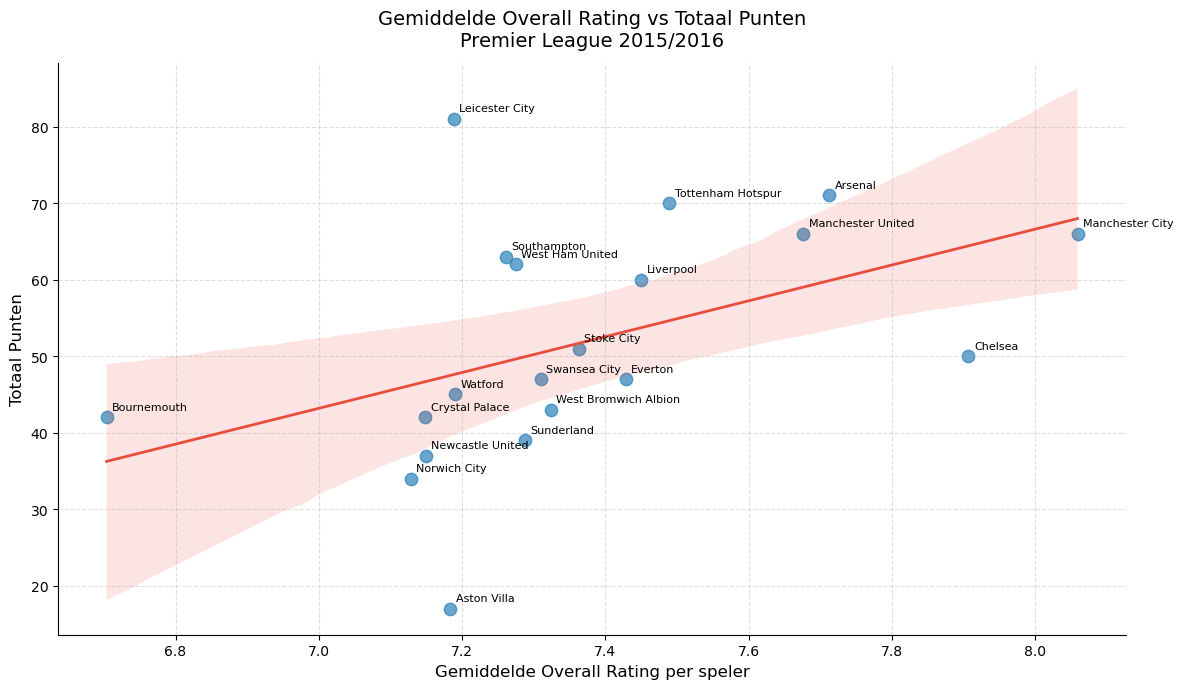

,team_long_name,totaal_punten,gem_overall_rating
0,Leicester City,81,7.188335
1,Arsenal,71,7.712065
2,Tottenham Hotspur,70,7.489534
3,Manchester City,66,8.059136
4,Manchester United,66,7.676135
5,Southampton,63,7.260825
6,West Ham United,62,7.275208
7,Liverpool,60,7.449750
8,Stoke City,51,7.362770
9,Chelsea,50,7.906921


In [97]:
# Visualisatie 1: Overall Rating vs Totaal Punten (Premier League 2015/2016)
LEAGUE_ID = 1729
SEIZOEN = '2015/2016'

df_vis1, col1 = maak_punten_stat_df(df_matches_rated, df_teams, LEAGUE_ID, SEIZOEN, 'overall_rating')
visualiseer_punten_vs_stat(df_vis1, col1, 'Overall Rating', SEIZOEN)
df_vis1[['team_long_name', 'totaal_punten', col1]].sort_values('totaal_punten', ascending=False).reset_index(drop=True)

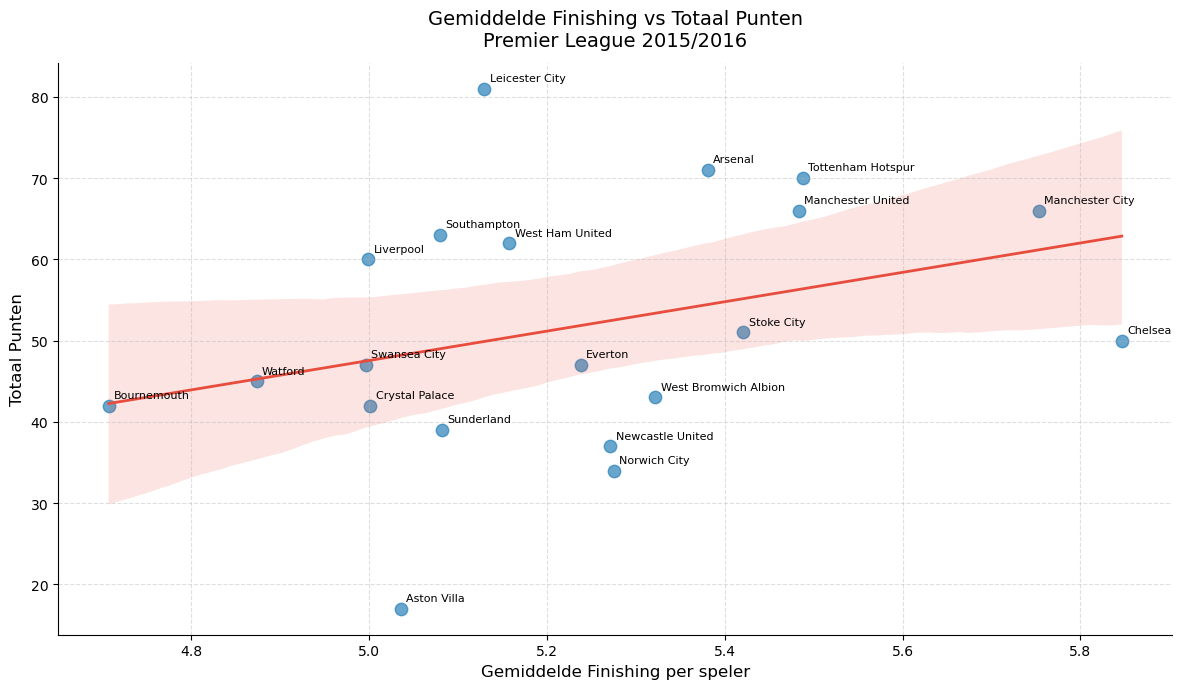

,team_long_name,totaal_punten,gem_finishing
0,Leicester City,81,5.129158
1,Arsenal,71,5.380731
2,Tottenham Hotspur,70,5.487603
3,Manchester City,66,5.752935
4,Manchester United,66,5.483084
5,Southampton,63,5.079257
6,West Ham United,62,5.157505
7,Liverpool,60,4.998973
8,Stoke City,51,5.420744
9,Chelsea,50,5.846614


In [98]:
# Visualisatie 2: Finishing vs Totaal Punten (Premier League 2015/2016)
df_vis2, col2 = maak_punten_stat_df(df_matches_rated, df_teams, LEAGUE_ID, SEIZOEN, 'finishing')
visualiseer_punten_vs_stat(df_vis2, col2, 'Finishing', SEIZOEN)
df_vis2[['team_long_name', 'totaal_punten', col2]].sort_values('totaal_punten', ascending=False).reset_index(drop=True)

### Interpretatie voor de technisch directeur

**Visualisatie 1: Gemiddelde Overall Rating vs Totaal Punten (Premier League 2015/2016)**

De eerste grafiek laat een duidelijk **positief verband** zien tussen de gemiddelde overall rating van de spelerskern en het aantal behaalde punten. Teams met een hogere gemiddelde spelerskwaliteit eindigen doorgaans hoger op de ranglijst. Leicester City vormt een opvallende uitzondering: ondanks een relatief lagere gemiddelde rating wonnen zij de competitie met 81 punten. Dit bevestigt dat een sterke spelerskern een goede indicator is voor succes, maar dat factoren zoals teamsamenhang, tactiek en fitheid ook een grote rol spelen.

**Visualisatie 2: Gemiddelde Finishing vs Totaal Punten (Premier League 2015/2016)**

De tweede grafiek toont het verband tussen de gemiddelde afrondings-kwaliteit (finishing) van de spelers en het puntenaantal. Ook hier is een **positief verband** zichtbaar: teams waarvan de spelers beter kunnen afronden, behalen meer punten. Dit is inhoudelijk logisch — spelers die kansen beter afmaken zetten mogelijkheden vaker om in doelpunten, wat direct leidt tot meer overwinningen.

**Conclusie voor de technisch directeur:**

Beide statistieken bevestigen dat investeren in hogere spelerskwaliteit — zowel de algemene spelersrating als de afrondings-kwaliteit — gecorreleerd is met meer punten. Om volgend seizoen meer punten te halen, is het aantrekken van spelers met een hogere overall rating én betere finishing een onderbouwde strategie. Tegelijkertijd laat Leicester City zien dat een slim samengesteld team soms beter presteert dan verwacht op basis van individuele statistieken.
